In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

from torch.optim import Adam
from torchvision.transforms import transforms
from PIL import Image

import os

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/animal-faces")

print("Path to dataset files:", path)

Resuming download from 5242880 bytes (724457875 bytes left)...
Resuming download to C:\Users\ankit\.cache\kagglehub\datasets\andrewmvd\animal-faces\1.archive (5242880/729700755) bytes left.


100%|██████████| 696M/696M [24:32<00:00, 492kB/s]   

Extracting files...


Path to dataset files: C:\Users\ankit\.cache\kagglehub\datasets\andrewmvd\animal-faces\versions\1


In [9]:
path = os.path.join(path,"afhq")

In [10]:
image_path = []
labels = []

for i in os.listdir(f"{path}"):
    for label in os.listdir(f"{path}/{i}"):
        for image in os.listdir(f"{path}/{i}/{label}"):
            image_path.append(f"{path}/{i}/{label}/{image}")
            labels.append(label)

df = pd.DataFrame(zip(image_path, labels), columns = ['image_path', 'labels'])

In [11]:
df.sample(10)

,image_path,labels
8806,C:\Users\ankit\.cache\kagglehub\datasets\andre...,dog
13052,C:\Users\ankit\.cache\kagglehub\datasets\andre...,wild
5956,C:\Users\ankit\.cache\kagglehub\datasets\andre...,dog
14461,C:\Users\ankit\.cache\kagglehub\datasets\andre...,wild
13241,C:\Users\ankit\.cache\kagglehub\datasets\andre...,wild
15487,C:\Users\ankit\.cache\kagglehub\datasets\andre...,dog
8136,C:\Users\ankit\.cache\kagglehub\datasets\andre...,dog
15465,C:\Users\ankit\.cache\kagglehub\datasets\andre...,dog
3643,C:\Users\ankit\.cache\kagglehub\datasets\andre...,cat
14141,C:\Users\ankit\.cache\kagglehub\datasets\andre...,wild


In [12]:
df['labels'].unique()

<ArrowStringArray>
['cat', 'dog', 'wild']
Length: 3, dtype: str

In [13]:
train, temp = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['labels']
)

val, test = train_test_split(
    temp, test_size=0.5, random_state=42, stratify=temp['labels']
)

In [14]:
print(train.shape) # 70%
print(test.shape) # 15%
print(val.shape) # 15%

(11291, 2)
(2420, 2)
(2419, 2)


In [15]:
label_encoder = LabelEncoder() # Encode the string classes to numeric
label_encoder.fit(df['labels']) # Fit the label encoder on our own data

transform = transforms.Compose([
    transforms.Resize((128, 128)), # One size for all images
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.ConvertImageDtype(torch.float) # The values are in floating point numbers
    ]) # Transform all images into one clear format (preprocess all images to same properties)
     

In [16]:
class MyData(Dataset):
    def __init__(self,dataframe,transform = None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self,idx):
        img_path = self.dataframe.iloc[idx,0]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image).to(device)

        return image, label


In [17]:
train_dataset = MyData(dataframe=train, transform= transform)
val_dataset = MyData(dataframe=val, transform= transform)
test_dataset = MyData(dataframe=test, transform= transform)

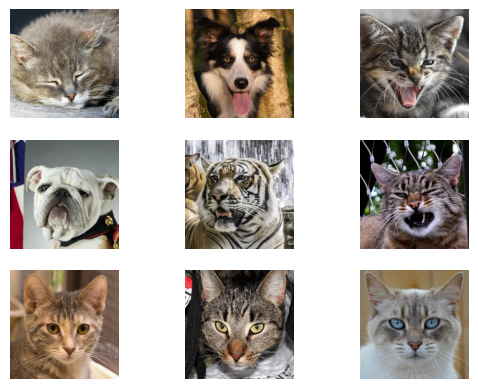

In [18]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(df.sample(n=1)['image_path'].iloc[0]).convert("RGB")
        axarr[row, col].imshow(image)
        axarr[row, col].axis('off')

plt.show()

In [19]:
LR = 1e-4
Batch_size=16
EPOCHS=10

In [20]:
train_loader = DataLoader(train_dataset, batch_size=Batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=True)

In [21]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size= 3, padding = 1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size= 3, padding = 1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size= 3, padding = 1)

        self.pooling  = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self. flatten = nn.Flatten()
        self.linear = nn.Linear((128*16*16),128)
        self.output = nn.Linear(128, len(df['labels'].unique()))

    def forward(self, x):
        x = self.conv1(x) #-> (32, 128, 128)
        x = self.pooling(x) #-> (32, 64, 64)
        x = self.relu(x)

        x = self.conv2(x) #-> (64, 64, 64)
        x = self.pooling(x) #-> (64, 32, 32)
        x = self.relu(x)

        x = self.conv3(x) #-> (128, 32, 32)
        x = self.pooling(x) #-> (128, 16, 16)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.output(x)

        return x



In [22]:
model = Net().to(device)

In [27]:
from torchsummary import summary
summary(model, input_size= (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [29]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}
              Validation Loss: {round(total_loss_val/100, 4)} Validation Accuracy: {round((total_acc_val)/val_dataset.__len__() * 100, 4)}''')
  print("="*25)

Epoch 1/10, Train Loss: 2.6118 Train Accuracy 85.3866
              Validation Loss: 0.4672 Validation Accuracy: 88.5076
Epoch 2/10, Train Loss: 1.0605 Train Accuracy 94.5709
              Validation Loss: 0.2058 Validation Accuracy: 94.8739
Epoch 3/10, Train Loss: 0.8475 Train Accuracy 95.5451
              Validation Loss: 0.1789 Validation Accuracy: 95.8247
Epoch 4/10, Train Loss: 0.6546 Train Accuracy 96.7762
              Validation Loss: 0.1743 Validation Accuracy: 96.0728
Epoch 5/10, Train Loss: 0.5592 Train Accuracy 97.2545
              Validation Loss: 0.1535 Validation Accuracy: 96.3208
Epoch 6/10, Train Loss: 0.4449 Train Accuracy 97.6441
              Validation Loss: 0.1553 Validation Accuracy: 96.3208
Epoch 7/10, Train Loss: 0.4352 Train Accuracy 97.8478
              Validation Loss: 0.1387 Validation Accuracy: 96.4448
Epoch 8/10, Train Loss: 0.3572 Train Accuracy 98.1667
              Validation Loss: 0.183 Validation Accuracy: 95.9074
Epoch 9/10, Train Loss: 0.3378 Tr

In [30]:
torch.save(model.state_dict(), "model.pth")

In [31]:
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [32]:
model.eval()

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=32768, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=3, bias=True)
)

In [33]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")
     

Accuracy Score is: 97.4793 and Loss is 0.0114


Plotting Training Progress

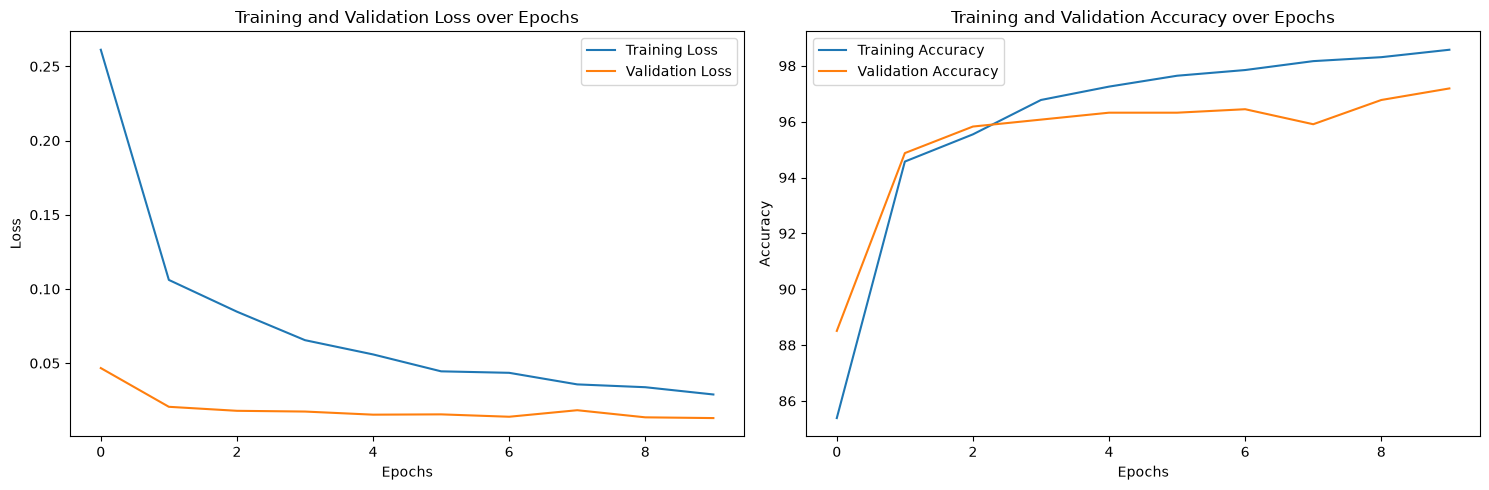

In [34]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()

we will be doing the inference. We can get a random image from the internet and see the prediction of it. Again, the model may not be very good as the goal is to get used to PyTorch syntax. You can modify the model architecture and training loop and see the results

In [35]:
# Predict function

def predict_image(image_path):

    image = Image.open(image_path).convert('RGB')

    image = transform(image).to(device)

    image = image.unsqueeze(0)

    model.eval()

    with torch.no_grad():

        output = model(image)

        probs = torch.softmax(output, dim=1)

        pred = torch.argmax(probs, dim=1).item()

    prediction = label_encoder.inverse_transform([pred])[0]

    return prediction, probs, pred




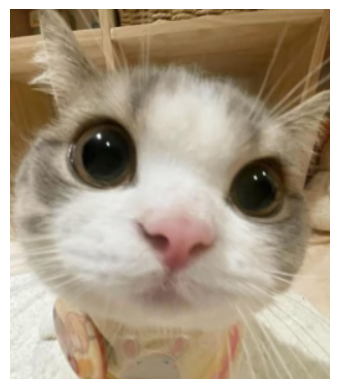


Prediction:

Prediction: cat
Raw Output: tensor([[9.0509e-01, 9.4885e-02, 2.7329e-05]], device='cuda:0')
Predicted Index: 0


In [39]:
# Visualize image
image = Image.open("Cat.png")

plt.imshow(image)
plt.axis('off')
plt.show()


# Predict
print("\nPrediction:\n")

prediction, output, pred = predict_image("Cat.png")

print("Prediction:", prediction)

print("Raw Output:", output)

print("Predicted Index:", pred)

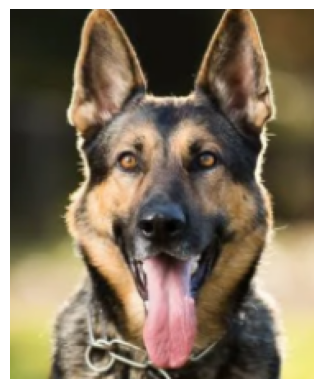


Prediction:

Prediction: dog
Raw Output: tensor([[2.5672e-08, 9.9986e-01, 1.3722e-04]], device='cuda:0')
Predicted Index: 1


In [37]:
# Visualize image
image = Image.open("Dog.png")

plt.imshow(image)
plt.axis('off')
plt.show()


# Predict
print("\nPrediction:\n")

prediction, output, pred = predict_image("Dog.png")

print("Prediction:", prediction)

print("Raw Output:", output)

print("Predicted Index:", pred)

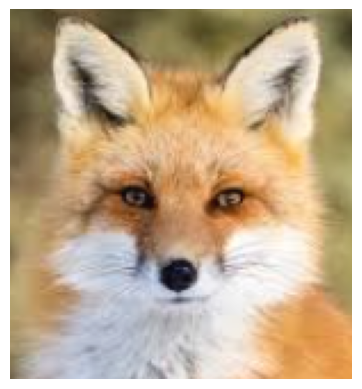


Prediction:

Prediction: wild
Raw Output: tensor([[1.4984e-04, 5.4274e-06, 9.9984e-01]], device='cuda:0')
Predicted Index: 2


In [38]:
# Visualize image
image = Image.open("fox.png")

plt.imshow(image)
plt.axis('off')
plt.show()


# Predict
print("\nPrediction:\n")

prediction, output, pred = predict_image("fox.png")

print("Prediction:", prediction)

print("Raw Output:", output)

print("Predicted Index:", pred)